# ResNet50 Fish Quality Training With Visualizations

This notebook is the ResNet baseline experiment. It follows the same research flow as the EfficientNet notebook: load CSV splits, train the model, record training history, evaluate on the test set, draw charts, and compare with EfficientNet. The purpose is to prove that ResNet was tested and EfficientNet was finally selected because it gave better/suitable performance.

## 1. Install / Import Libraries

In [2]:
import os
import random
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

try:
    from torch.amp import autocast, GradScaler
    USE_NEW_AMP = True
except ImportError:
    from torch.cuda.amp import autocast, GradScaler
    USE_NEW_AMP = False

import timm

warnings.filterwarnings('ignore')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
CUDA available: False


## 2. Configuration

The notebook uses `resnet50` as the baseline backbone. For viva/demo speed, Stage 3 grade training is enabled by default. Stage 1 and Stage 2 code is included and can be enabled if full ResNet multi-stage training is required.

In [ ]:
# Resolve paths from this notebook location:
# model/fish_quality_grade/data_csv/train/resnet_train.ipynb
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'train':
    FISH_QUALITY_DIR = NOTEBOOK_DIR.parents[1]
else:
    FISH_QUALITY_DIR = Path(r'C:/Users/User/Desktop/Research Final Year/Test RP/model/fish_quality_grade')

DATA_DIR = FISH_QUALITY_DIR / 'data_csv'
RESULTS_DIR = FISH_QUALITY_DIR / 'resnet_results_notebook'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_TRAIN_CSV = DATA_DIR / 'stage1_train.csv'
STAGE1_VAL_CSV = DATA_DIR / 'stage1_val.csv'
STAGE1_TEST_CSV = DATA_DIR / 'stage1_test.csv'

STAGE2_TRAIN_CSV = DATA_DIR / 'stage2_species_train.csv'
STAGE2_VAL_CSV = DATA_DIR / 'stage2_species_val.csv'
STAGE2_TEST_CSV = DATA_DIR / 'stage2_species_test.csv'

STAGE3_TRAIN_CSV = DATA_DIR / 'stage3_grade_train.csv'
STAGE3_VAL_CSV = DATA_DIR / 'stage3_grade_val.csv'
STAGE3_TEST_CSV = DATA_DIR / 'stage3_grade_test.csv'

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10         
FREEZE_EPOCHS = 2
PATIENCE = 5

HEAD_LR = 2e-4
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3
LABEL_SMOOTHING = 0.05
NUM_WORKERS = 0
SEED = 42

BACKBONE = 'resnet50'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Train switches. Stage 3 is the most important for quality grading comparison.
RUN_STAGE1 = False
RUN_STAGE2 = False
RUN_STAGE3 = True

STAGE1_MODEL_PATH = RESULTS_DIR / 'resnet_stage1_binary_best.pth'
STAGE2_MODEL_PATH = RESULTS_DIR / 'resnet_stage2_species_best.pth'
STAGE3_MODEL_PATH = RESULTS_DIR / 'resnet_stage3_grade_best.pth'

print('Fish quality directory:', FISH_QUALITY_DIR)
print('Data directory:', DATA_DIR)
print('Results directory:', RESULTS_DIR)
print('Device:', DEVICE)
print('Backbone:', BACKBONE)

Fish quality directory: c:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade
Data directory: c:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv
Results directory: c:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\resnet_results_notebook
Device: cpu
Backbone: resnet50


## 3. Reproducibility

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## 4. Inspect Dataset Splits

These are the same prepared train/validation/test CSV files used for the final model experiment. Using the same split makes ResNet and EfficientNet comparison fair.

In [5]:
def show_split(csv_path, label_column):
    df = pd.read_csv(csv_path)
    print(f'{csv_path.name}: {len(df)} rows')
    print(df[label_column].value_counts().sort_index())
    print()
    return df

stage3_train_preview = show_split(STAGE3_TRAIN_CSV, 'grade_label')
stage3_val_preview = show_split(STAGE3_VAL_CSV, 'grade_label')
stage3_test_preview = show_split(STAGE3_TEST_CSV, 'grade_label')

stage3_grade_train.csv: 547 rows
grade_label
A    177
B    213
C    157
Name: count, dtype: int64

stage3_grade_val.csv: 117 rows
grade_label
A    38
B    45
C    34
Name: count, dtype: int64

stage3_grade_test.csv: 118 rows
grade_label
A    38
B    46
C    34
Name: count, dtype: int64



## 5. Dataset Class

Each row has `left_image`, `right_image`, and a label column. This matches the dual-view model design used in the research.

In [6]:
class FishDataset(Dataset):
    def __init__(self, dataframe, label_column, transform=None, class_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_column = label_column
        self.transform = transform

        self.df[label_column] = self.df[label_column].astype(str)
        if class_to_idx is None:
            self.unique_labels = sorted(self.df[label_column].unique())
            self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_labels)}
        else:
            self.label_to_idx = class_to_idx
            self.unique_labels = [label for label, _ in sorted(class_to_idx.items(), key=lambda x: x[1])]
            self.df = self.df[self.df[label_column].isin(self.label_to_idx.keys())].reset_index(drop=True)

        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        print(f'[{label_column}] Classes:', self.unique_labels)
        print(f'[{label_column}] Distribution:', dict(sorted(Counter(self.df[label_column]).items())))

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        try:
            if not isinstance(path, str) or not os.path.exists(path):
                return Image.new('RGB', (IMG_SIZE, IMG_SIZE), color='black')
            return Image.open(path).convert('RGB')
        except Exception:
            return Image.new('RGB', (IMG_SIZE, IMG_SIZE), color='black')

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        left_img = self._load_image(row['left_image'])
        right_img = self._load_image(row['right_image'])

        if self.transform:
            left_img = self.transform(left_img)
            right_img = self.transform(right_img)

        label = self.label_to_idx[row[self.label_column]]
        return left_img, right_img, torch.tensor(label, dtype=torch.long)

## 6. Dual-View ResNet50 Model

The backbone is ResNet50. Features from the left and right images are fused using weighted feature fusion: left features, right features, absolute difference, and element-wise product.

In [7]:
class DualViewClassifier(nn.Module):
    def __init__(self, backbone_name='resnet50', num_classes=2, dropout_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feat_dim = self.backbone(dummy).shape[1]

        fused_dim = feat_dim * 4

        self.attention = nn.Sequential(
            nn.Linear(feat_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 2),
            nn.Softmax(dim=1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.8),
            nn.Linear(256, num_classes),
        )

        self.aux_left = nn.Linear(feat_dim, num_classes)
        self.aux_right = nn.Linear(feat_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, left, right, return_aux=False):
        f_left = self.backbone(left)
        f_right = self.backbone(right)

        pair = torch.cat([f_left, f_right], dim=1)
        weights = self.attention(pair)
        f_left_w = f_left * weights[:, 0].unsqueeze(1)
        f_right_w = f_right * weights[:, 1].unsqueeze(1)

        diff = torch.abs(f_left_w - f_right_w)
        prod = f_left_w * f_right_w
        fused = torch.cat([f_left_w, f_right_w, diff, prod], dim=1)
        logits = self.classifier(fused)

        if return_aux:
            return logits, self.aux_left(f_left), self.aux_right(f_right)
        return logits

## 7. Data Preparation Helpers

In [8]:
def load_and_filter_dataframe(csv_path, label_column, stage_name):
    df = pd.read_csv(csv_path)
    required_cols = [label_column, 'left_image', 'right_image']
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    if stage_name == 'stage2':
        invalid_species = {'none', 'non_fish', 'background', 'no_fish', 'not_fish', 'unknown'}
        df = df[~df[label_column].astype(str).str.lower().isin(invalid_species)].reset_index(drop=True)
        if 'binary_label' in df.columns:
            df = df[df['binary_label'].astype(str).str.lower().isin({'fish', '1', 'true', 'yes'})].reset_index(drop=True)

    if stage_name == 'stage3':
        df = df[df[label_column].astype(str).isin({'A', 'B', 'C'})].reset_index(drop=True)
        if 'species_label' in df.columns:
            df = df[df['species_label'].astype(str).str.lower() != 'none'].reset_index(drop=True)
        if 'binary_label' in df.columns:
            df = df[df['binary_label'].astype(str).str.lower().isin({'fish', '1', 'true', 'yes'})].reset_index(drop=True)

    print(f'Filtered rows for {stage_name}:', len(df))
    print('Label counts:', dict(sorted(Counter(df[label_column]).items())))
    return df


def build_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(5),
        transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_transform, val_transform

## 8. Metrics, Training, Validation, and Plot Functions

In [9]:
def compute_metrics(all_labels, all_preds):
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    acc = (all_labels == all_preds).mean()
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, bal_acc, macro_f1, weighted_f1


def build_optimizer(model, backbone_frozen=True):
    if backbone_frozen:
        for param in model.backbone.parameters():
            param.requires_grad = False
        return AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)

    for param in model.backbone.parameters():
        param.requires_grad = True
    return AdamW([
        {'params': model.backbone.parameters(), 'lr': BACKBONE_LR},
        {'params': model.attention.parameters(), 'lr': HEAD_LR},
        {'params': model.classifier.parameters(), 'lr': HEAD_LR},
        {'params': model.aux_left.parameters(), 'lr': HEAD_LR},
        {'params': model.aux_right.parameters(), 'lr': HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)


def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for left, right, labels in loader:
        left, right, labels = left.to(DEVICE), right.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        if USE_NEW_AMP:
            with autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                logits, aux_left, aux_right = model(left, right, return_aux=True)
                loss = criterion(logits, labels) + 0.2 * criterion(aux_left, labels) + 0.2 * criterion(aux_right, labels)
        else:
            with autocast(enabled=(DEVICE == 'cuda')):
                logits, aux_left, aux_right = model(left, right, return_aux=True)
                loss = criterion(logits, labels) + 0.2 * criterion(aux_left, labels) + 0.2 * criterion(aux_right, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for left, right, labels in loader:
            left, right, labels = left.to(DEVICE), right.to(DEVICE), labels.to(DEVICE)
            if USE_NEW_AMP:
                with autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                    logits = model(left, right)
                    loss = criterion(logits, labels)
            else:
                with autocast(enabled=(DEVICE == 'cuda')):
                    logits = model(left, right)
                    loss = criterion(logits, labels)

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    acc, bal_acc, macro_f1, weighted_f1 = compute_metrics(all_labels, all_preds)
    return total_loss / total_samples, acc, bal_acc, macro_f1, weighted_f1, all_preds, all_labels

In [10]:
def stage_dir(stage_name):
    out = RESULTS_DIR / stage_name
    out.mkdir(parents=True, exist_ok=True)
    return out


def plot_training_history(history, stage_name):
    out = stage_dir(stage_name)
    hist = pd.DataFrame(history)
    hist.to_csv(out / f'{stage_name}_training_history.csv', index=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'ResNet50 {stage_name.upper()} Training Metrics', fontsize=16, fontweight='bold')

    axes[0, 0].plot(hist['epoch'], hist['train_loss'], marker='o', label='Train Loss')
    axes[0, 0].plot(hist['epoch'], hist['val_loss'], marker='o', label='Val Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(hist['epoch'], hist['train_acc'], marker='o', label='Train Acc')
    axes[0, 1].plot(hist['epoch'], hist['val_acc'], marker='o', label='Val Acc')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(hist['epoch'], hist['val_bal_acc'], marker='o', label='Val Balanced Acc')
    axes[1, 0].set_title('Balanced Accuracy')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(hist['epoch'], hist['val_macro_f1'], marker='o', label='Val Macro F1')
    axes[1, 1].plot(hist['epoch'], hist['val_weighted_f1'], marker='o', label='Val Weighted F1')
    axes[1, 1].set_title('F1 Scores')
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel('Epoch')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    save_path = out / f'{stage_name}_training_curves.png'
    fig.savefig(save_path, dpi=180)
    plt.show()
    print('Saved:', save_path)


def plot_confusion_matrix(test_labels, test_preds, target_names, stage_name):
    out = stage_dir(stage_name)
    cm = confusion_matrix(test_labels, test_preds)
    pd.DataFrame(cm, index=target_names, columns=target_names).to_csv(out / f'{stage_name}_confusion_matrix.csv')
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'ResNet50 {stage_name.upper()} Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_path = out / f'{stage_name}_confusion_matrix.png'
    fig.savefig(save_path, dpi=180)
    plt.show()
    print('Saved:', save_path)


def save_report(test_labels, test_preds, target_names, stage_name):
    out = stage_dir(stage_name)
    text = classification_report(test_labels, test_preds, target_names=target_names, digits=4, zero_division=0)
    report_dict = classification_report(test_labels, test_preds, target_names=target_names, digits=4, output_dict=True, zero_division=0)
    (out / f'{stage_name}_classification_report.txt').write_text(text, encoding='utf-8')
    pd.DataFrame(report_dict).transpose().to_csv(out / f'{stage_name}_classification_report.csv')
    print(text)
    return text

## 9. Train One Stage

This function trains one ResNet stage and saves all visual metrics.

In [11]:
def train_stage(train_csv, val_csv, test_csv, label_column, model_save_path, stage_name):
    print('\n' + '=' * 90)
    print('TRAINING', stage_name.upper())
    print('=' * 90)

    train_df = load_and_filter_dataframe(train_csv, label_column, stage_name)
    val_df = load_and_filter_dataframe(val_csv, label_column, stage_name)
    test_df = load_and_filter_dataframe(test_csv, label_column, stage_name)

    train_transform, val_transform = build_transforms()

    train_dataset = FishDataset(train_df, label_column, transform=train_transform)
    val_dataset = FishDataset(val_df, label_column, transform=val_transform, class_to_idx=train_dataset.label_to_idx)
    test_dataset = FishDataset(test_df, label_column, transform=val_transform, class_to_idx=train_dataset.label_to_idx)

    num_classes = len(train_dataset.unique_labels)
    target_names = [train_dataset.idx_to_label[i] for i in range(num_classes)]

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))

    model = DualViewClassifier(BACKBONE, num_classes=num_classes, dropout_rate=DROPOUT_RATE).to(DEVICE)

    train_labels = [train_dataset.label_to_idx[v] for v in train_df[label_column].astype(str).tolist()]
    class_counts = Counter(train_labels)
    class_weights = torch.tensor([
        len(train_labels) / (num_classes * class_counts.get(i, 1))
        for i in range(num_classes)
    ], dtype=torch.float32, device=DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = build_optimizer(model, backbone_frozen=True)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
    scaler = GradScaler(enabled=(DEVICE == 'cuda'))

    best_metric_name = 'balanced_accuracy' if stage_name == 'stage1' else 'macro_f1'
    best_metric = -1.0
    best_epoch = 0
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print(f'\n>>> Unfreezing ResNet50 backbone at epoch {epoch} <<<\n')
            optimizer = build_optimizer(model, backbone_frozen=False)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, val_bal_acc, val_macro_f1, val_weighted_f1, _, _ = validate_epoch(model, val_loader, criterion)

        selected_metric = val_bal_acc if best_metric_name == 'balanced_accuracy' else val_macro_f1
        scheduler.step(selected_metric)

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_bal_acc': val_bal_acc,
            'val_macro_f1': val_macro_f1,
            'val_weighted_f1': val_weighted_f1,
            'selected_metric': selected_metric,
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Bal Acc: {val_bal_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} | "
            f"Val Weighted F1: {val_weighted_f1:.4f}"
        )

        if selected_metric > best_metric:
            best_metric = selected_metric
            best_epoch = epoch
            torch.save({
                'model_state_dict': model.state_dict(),
                'backbone': BACKBONE,
                'img_size': IMG_SIZE,
                'num_classes': num_classes,
                'label_to_idx': train_dataset.label_to_idx,
                'idx_to_label': train_dataset.idx_to_label,
                'stage_name': stage_name,
                'best_metric_name': best_metric_name,
                'best_metric_value': best_metric,
            }, model_save_path)
            print(f'   New best ResNet model saved! ({best_metric_name}: {best_metric:.4f})')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print('Early stopping triggered')
            break

    print(f'Best epoch: {best_epoch} | Best {best_metric_name}: {best_metric:.4f}')
    plot_training_history(history, stage_name)

    checkpoint = torch.load(model_save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    test_loss, test_acc, test_bal_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = validate_epoch(model, test_loader, criterion)

    print('\nTEST RESULTS')
    print(f'Loss: {test_loss:.4f}')
    print(f'Accuracy: {test_acc:.4f}')
    print(f'Balanced Accuracy: {test_bal_acc:.4f}')
    print(f'Macro F1: {test_macro_f1:.4f}')
    print(f'Weighted F1: {test_weighted_f1:.4f}')

    plot_confusion_matrix(test_labels, test_preds, target_names, stage_name)
    report_text = save_report(test_labels, test_preds, target_names, stage_name)

    metrics = {
        'stage': stage_name,
        'backbone': BACKBONE,
        'best_epoch': best_epoch,
        'best_metric_name': best_metric_name,
        'best_metric_value': float(best_metric),
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'test_balanced_accuracy': float(test_bal_acc),
        'test_macro_f1': float(test_macro_f1),
        'test_weighted_f1': float(test_weighted_f1),
        'classes': target_names,
        'model_path': str(model_save_path),
    }
    (stage_dir(stage_name) / f'{stage_name}_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    return model, train_dataset.label_to_idx, train_dataset.idx_to_label, metrics

## 10. Train ResNet50 Model

For the viva comparison, Stage 3 grade classification is the most important result because the final system outputs quality grade `A`, `B`, or `C`.


TRAINING STAGE3
Filtered rows for stage3: 547
Label counts: {'A': 177, 'B': 213, 'C': 157}
Filtered rows for stage3: 117
Label counts: {'A': 38, 'B': 45, 'C': 34}
Filtered rows for stage3: 118
Label counts: {'A': 38, 'B': 46, 'C': 34}
[grade_label] Classes: ['A', 'B', 'C']
[grade_label] Distribution: {'A': 177, 'B': 213, 'C': 157}
[grade_label] Classes: ['A', 'B', 'C']
[grade_label] Distribution: {'A': 38, 'B': 45, 'C': 34}
[grade_label] Classes: ['A', 'B', 'C']
[grade_label] Distribution: {'A': 38, 'B': 46, 'C': 34}
Epoch 01/10 | Train Loss: 1.3911 | Train Acc: 0.5795 | Val Loss: 0.7912 | Val Acc: 0.8205 | Val Bal Acc: 0.8311 | Val Macro F1: 0.8234 | Val Weighted F1: 0.8241
   New best ResNet model saved! (macro_f1: 0.8234)
Epoch 02/10 | Train Loss: 0.9676 | Train Acc: 0.8300 | Val Loss: 0.4488 | Val Acc: 0.9145 | Val Bal Acc: 0.9211 | Val Macro F1: 0.9138 | Val Weighted F1: 0.9139
   New best ResNet model saved! (macro_f1: 0.9138)

>>> Unfreezing ResNet50 backbone at epoch 3 <<<

Ep

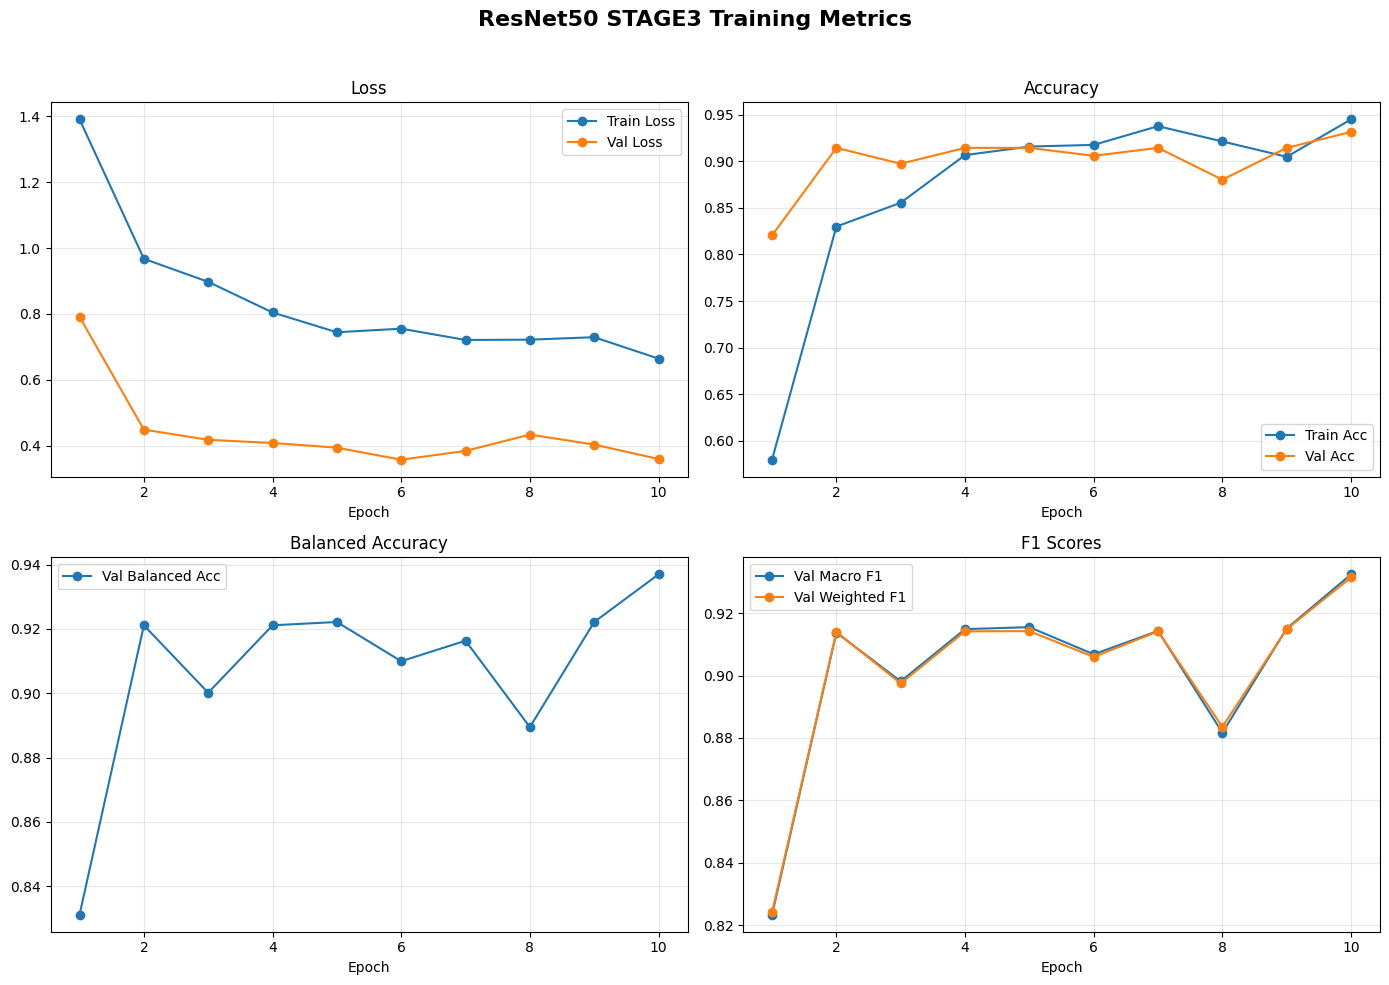

Saved: c:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\resnet_results_notebook\stage3\stage3_training_curves.png

TEST RESULTS
Loss: 0.3578
Accuracy: 0.9153
Balanced Accuracy: 0.9209
Macro F1: 0.9163
Weighted F1: 0.9152


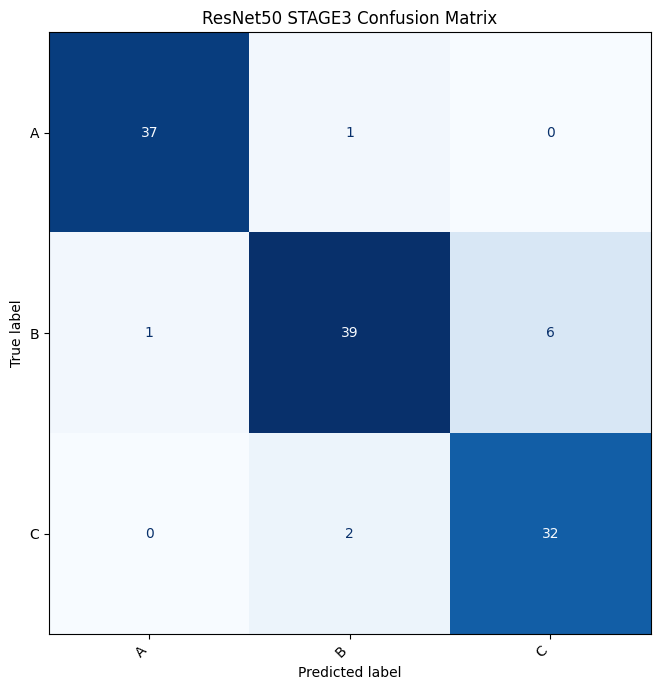

Saved: c:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\resnet_results_notebook\stage3\stage3_confusion_matrix.png
              precision    recall  f1-score   support

           A     0.9737    0.9737    0.9737        38
           B     0.9286    0.8478    0.8864        46
           C     0.8421    0.9412    0.8889        34

    accuracy                         0.9153       118
   macro avg     0.9148    0.9209    0.9163       118
weighted avg     0.9182    0.9153    0.9152       118



,stage,backbone,best_epoch,best_metric_name,best_metric_value,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,classes,model_path
0,stage3,resnet50,10,macro_f1,0.932443,0.357818,0.915254,0.920896,0.916312,0.915211,"[A, B, C]",c:\Users\User\Desktop\Research Final Year\Test...


In [12]:
summary_rows = []

if RUN_STAGE1:
    _, stage1_label_map, stage1_idx_map, stage1_metrics = train_stage(
        STAGE1_TRAIN_CSV, STAGE1_VAL_CSV, STAGE1_TEST_CSV,
        'binary_label', STAGE1_MODEL_PATH, 'stage1'
    )
    summary_rows.append(stage1_metrics)

if RUN_STAGE2:
    _, stage2_label_map, stage2_idx_map, stage2_metrics = train_stage(
        STAGE2_TRAIN_CSV, STAGE2_VAL_CSV, STAGE2_TEST_CSV,
        'species_label', STAGE2_MODEL_PATH, 'stage2'
    )
    summary_rows.append(stage2_metrics)

if RUN_STAGE3:
    stage3_model, stage3_label_map, stage3_idx_map, stage3_metrics = train_stage(
        STAGE3_TRAIN_CSV, STAGE3_VAL_CSV, STAGE3_TEST_CSV,
        'grade_label', STAGE3_MODEL_PATH, 'stage3'
    )
    summary_rows.append(stage3_metrics)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / 'resnet_summary_metrics.csv', index=False)
display(summary_df)

## 11. Summary Chart For ResNet Stages

In [ ]:
if len(summary_rows) > 0:
    metrics_to_plot = ['test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1']
    df = pd.DataFrame(summary_rows)
    x = np.arange(len(df['stage']))
    width = 0.18
    fig, ax = plt.subplots(figsize=(11, 6))
    for i, metric in enumerate(metrics_to_plot):
        ax.bar(x + (i - 1.5) * width, df[metric], width, label=metric.replace('test_', '').replace('_', ' ').title())
    ax.set_title('ResNet50 Test Metrics')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(df['stage'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_path = RESULTS_DIR / 'resnet_test_metrics_summary.png'
    fig.savefig(save_path, dpi=180)
    plt.show()
    print('Saved:', save_path)

## 12. EfficientNet vs ResNet50 Comparison

The existing EfficientNet notebook output showed grade classification accuracy around `0.9398`. This comparison chart supports the decision: ResNet50 was tested as a baseline, but EfficientNet-B0 was selected for the final application.

In [ ]:
# Update this value if you rerun EfficientNet and get a new final test accuracy.
efficientnet_grade_accuracy = 0.9398

if RUN_STAGE3 and 'stage3_metrics' in globals():
    resnet_grade_accuracy = stage3_metrics['test_accuracy']
    comparison_df = pd.DataFrame([
        {'Model': 'ResNet50 baseline', 'Grade Test Accuracy': resnet_grade_accuracy},
        {'Model': 'EfficientNet-B0 selected', 'Grade Test Accuracy': efficientnet_grade_accuracy},
    ])
    display(comparison_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#64748b', '#2563eb']
    bars = ax.bar(comparison_df['Model'], comparison_df['Grade Test Accuracy'], color=colors)
    ax.set_title('Fish Grade Accuracy: ResNet50 vs EfficientNet-B0')
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim(0, 1.05)
    for bar, value in zip(bars, comparison_df['Grade Test Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.02, f'{value:.2%}', ha='center', fontweight='bold')
    plt.xticks(rotation=8, ha='right')
    plt.tight_layout()
    save_path = RESULTS_DIR / 'resnet_vs_efficientnet_grade_accuracy.png'
    fig.savefig(save_path, dpi=180)
    plt.show()
    print('Saved:', save_path)
else:
    print('Run Stage 3 first to create ResNet grade metrics.')

## 13. Viva Explanation

- ResNet50 was trained as a baseline CNN architecture.
- The same train/validation/test CSV split was used for fairness.
- The model was evaluated using accuracy, balanced accuracy, macro F1, weighted F1, confusion matrix, and classification report.
- EfficientNet-B0 was selected for the final system because it provided better/suitable accuracy with a lighter and more deployment-friendly architecture.
- Therefore, the final model choice was experimental, not arbitrary.